In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

#Restricts the timesteps of the data from timesteps0 to 140
data=data.isel(time=np.arange(1,140+1))
parcel=parcel.isel(time=np.arange(1,140+1))

def grid_location(x,y,z):
    xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
    yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
    return which_zh,which_yh,which_xh
    
def grid_location(x,y,z): #faster
    #finding xf and yf
    ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
    xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
    dy=np.round(dy);dx=np.round(dx)

    #digitizing
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
    if which_zh.ndim==0:
        which_zh=np.array([which_zh])
    which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
    which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

    #fixing boundaries
    which_zh[np.where(which_zh==len(data['zh']))]-=1
    which_yh[np.where(which_yh==len(data['yh']))]-=1
    which_xh[np.where(which_xh==len(data['xh']))]-=1
    return which_zh,which_yh,which_xh
    
x=parcel['x'];y=parcel['y'];z=parcel['z']
which_z,which_y,which_x=grid_location(x,y,z)

In [81]:
griddist_x=[]
griddist_y=[]

#All Parcels Lagrangian Parcels Profile 
vars=['w','qv','qc','qi','th']
vars=['w']
types=['general','cloudy']
types=['cloudy']
for type in types:

    # #creates profile storage and adds z column  
    w_thresh=1 #m/s
    qcqi_thresh=1e-6 #kg/kg
    Nt=len(data['time'])
    Nz=len(data['zh'])
    Np=len(parcel['xh'])
    
    #create profile array
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    # for t in np.arange(Nt):
    for t in [33]:
        # if t==1: break #TESTING***
        for N in np.arange(Np):
            # if N==100:break #TESTING***
            if np.mod(N,100)==0: print(N)
            kh=which_z[t,N]
            jh=which_y[t,N]
            ih=which_x[t,N]
                    
            w_data=data['w'].isel(time=t).interp(zf=data['zh'])
            w_data=w_data.isel(zh=kh,yh=jh,xh=ih).item()
            var_data=w_data

            qv_data=data['qv'].isel(time=t,zh=kh,yh=jh,xh=ih)
            qc_data=data['qc'].isel(time=t,zh=kh,yh=jh,xh=ih)
            qi_data=data['qi'].isel(time=t,zh=kh,yh=jh,xh=ih)
            qcqi_data=qc_data+qi_data

            th_data=data['th'].isel(time=t,zh=kh,yh=jh,xh=ih)

            #globalize variables
            globals()['w_data'] = w_data
            globals()['qv_data'] = qv_data
            globals()['qc_data'] = qc_data
            globals()['qi_data'] = qi_data
            globals()['th_data'] = th_data
                  
            #if w_zdata greater than threshold, add to profile z column and add count
            if type=='general':
                if var_data>=w_thresh:
                    for var in vars:
                        globals()[f"profile_{var}"][kh,0]+=globals()[f"{var}_data"] #adds data to first column
                        globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column
            if type=='cloudy':
                if (var_data>=w_thresh) & (qcqi_data>=qcqi_thresh):
                    
                    #################################################################### #TESTING
                    irange=[ih.item()-1,ih.item()+1] #+-1 km box
                    jrange=[jh.item()-1,jh.item()+1] #+-1 km box
                    islice=slice(irange[0],irange[1]+1)
                    jslice=slice(jrange[0],jrange[1]+1)

                    if np.any(np.array(irange)<0) == False and np.any(np.array(jrange)<0) == False and np.any(np.array(irange)>511) == False and np.any(np.array(jrange)>90) == False:
                        box=data['w'].isel(time=t).interp(zf=data['zh']).isel(xh=islice,yh=jslice,zh=kh)
                        boxmax_x=np.where(box==np.max(box))[1].item()
                        boxmax_y=np.where(box==np.max(box))[0].item()
                        data_x=np.where(box==w_data)[1].item()
                        data_y=np.where(box==w_data)[0].item()
                    
                        griddist_x.append(data_x-boxmax_x)
                        griddist_y.append(data_y-boxmax_y)
                    ####################################################################
                    for var in vars:
                        globals()[f"profile_{var}"][kh,0]+=globals()[f"{var}_data"] #adds data to first column
                        globals()[f"profile_{var}"][kh,1]+=1 #adds +1 counter to 2nd column

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18500
18

In [94]:
directory=dir+'tracking_algorithms/'


# Save the array as an .npz file
np.savez(directory+'griddist_x_t33', array=np.array(griddist_x))
np.savez(directory+'griddist_y_t33.npz', array=np.array(griddist_y))

0.4

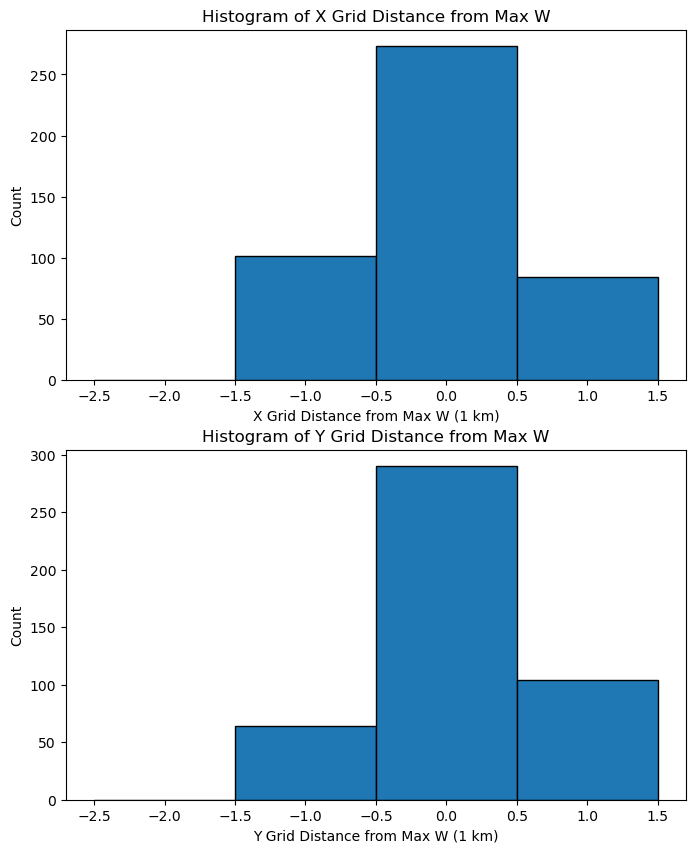

In [103]:

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Histogram for griddist_x
axs[0].hist(griddist_x, bins=range(-2, 3), edgecolor='black', align='left')
axs[0].set_ylabel('Count')
axs[0].set_xlabel('X Grid Distance from Max W (1 km)')
axs[0].set_title('Histogram of X Grid Distance from Max W')

# Histogram for griddist_y
axs[1].hist(griddist_y, bins=range(-2, 3), edgecolor='black', align='left')
axs[1].set_ylabel('Count')
axs[1].set_xlabel('Y Grid Distance from Max W (1 km)')
axs[1].set_title('Histogram of Y Grid Distance from Max W')

#about 200/500 = 40% of parcels are on left or right of the max W

Text(0.5, 1.0, 'Histogram of Y Grid Distance from Max W')

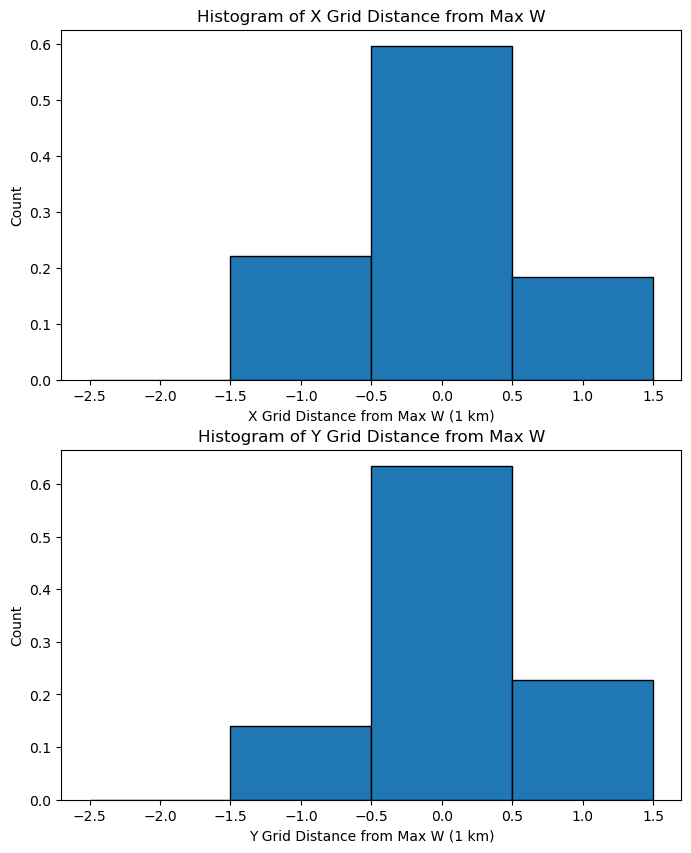

In [105]:

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Histogram for griddist_x
axs[0].hist(griddist_x, bins=range(-2, 3), edgecolor='black', align='left',density=True)
axs[0].set_ylabel('Count')
axs[0].set_xlabel('X Grid Distance from Max W (1 km)')
axs[0].set_title('Histogram of X Grid Distance from Max W')

# Histogram for griddist_y
axs[1].hist(griddist_y, bins=range(-2, 3), edgecolor='black', align='left',density=True)
axs[1].set_ylabel('Count')
axs[1].set_xlabel('Y Grid Distance from Max W (1 km)')
axs[1].set_title('Histogram of Y Grid Distance from Max W')

#about 200/500 = 40% of parcels are on left or right in x and y of the max W